In [1]:
# --- 0. Setup: Imports and NLTK Data ---

# Import main libraries

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import MDS
from sklearn.cluster import KMeans
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

# --- Download NLTK Data Packages ---
# These downloads are necessary for the script to run.
# 'punkt' is required for word_tokenize()
# 'wordnet' and 'omw-1.4' are required for WordNetLemmatizer()
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Colom\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Colom\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Colom\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

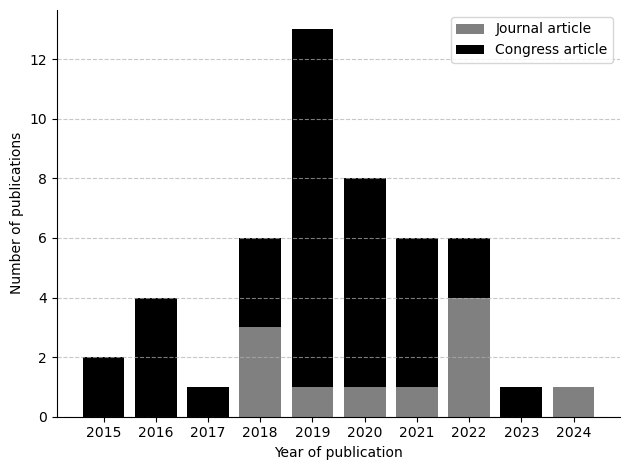

In [2]:
# --- 1. Plot Publication Types by Year (Generates Figure 1) ---
# This plot shows the distribution of publication types 
# (Journal vs. Congress articles) across the analyzed period.
# -----------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

# Define X-axis (years) in ascending order
x = np.array(["2015", "2016", "2017", "2018", "2019", "2020",
              "2021", "2022", "2023", "2024"])

# Define Y1 (Journal articles)
y1 = np.array([0, 0, 0, 3, 1, 1, 1, 4, 0, 1])

# Define Y2 (Congress articles)
y2 = np.array([2, 4, 1, 3, 12, 7, 5, 2, 1, 0])

# --- Totals Check (for verification) ---
# 2015: 0+2=2
# 2016: 0+4=4
# 2017: 0+1=1
# 2018: 3+3=6
# 2019: 1+12=13
# 2020: 1+7=8  
# 2021: 1+5=6  
# 2022: 4+2=6
# 2023: 0+1=1
# 2024: 1+0=1
# Total = 48 articles

fig, ax = plt.subplots()

# Clean up the plot aesthetics
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Create the stacked bars
plt.bar(x, y1, color="grey", label="Journal article")
plt.bar(x, y2, bottom=y1, color="black", label="Congress article")

# Set labels and legend
plt.ylabel("Number of publications")
plt.xlabel("Year of publication")
plt.legend() # Labels are taken from the 'label' param in plt.bar

# Ensure labels fit
plt.tight_layout() 

# Save the figure
plt.savefig('Type_of_article_distribution_by_year.png', dpi=300)
plt.show()

In [3]:
# --- 2. Corpus Preparation ---
# This cell defines the primary dataset for the review.
# It contains the 48 abstracts manually collected (the corpus)
# and their corresponding publication years.
# -----------------------------------------------------------------

#The corpus of 48 abstracts
corpus = ["In a decentralized household energy system comprised of various devices such as home appliances, electric vehicles, and solar panels, end-users are able to dig deeper into the system’s details and further achieve energy sustainability if they are presented with data on the electric energy consumption and production at the granularity of the device. However, many databases in this field are siloed from other domains, including solely information pertaining to energy. This may result in the loss of information (e.g. weather) on each device’s energy use. Meanwhile, a large number of these datasets have been extensively used in computational modeling techniques such as machine learning models. While such computational approaches achieve great accuracy and performance by concentrating only on a local view of datasets, model reliability cannot be guaranteed since such models are very vulnerable to data input fluctuations when information omission is taken into account. This article tackles the data isolation issue in the field of smart energy systems by examining Semantic Web methods on top of a household energy system. We offer an ontology-based approach for managing decentralized data at the device-level resolution in a system. As a consequence, the scope of the data associated with each device may easily be expanded in an interoperable manner throughout the Web, and additional information, such as weather, can be obtained from the Web, provided that the data is organized according to W3C standards.",
        "In this paper we present AMALGAM, a matching approach to fairify tabular data with the use of a knowledge graph. The ultimate goal is to provide fast and e cient approach to annotate tabular data withentities from a background knowledge. The approach combines lookup and ltering services combined with text pre-processing techniques. Experiments conducted in the context of the 2020 Semantic Web Challenge on Tabular Data to Knowledge Graph Matching with both Column Type Annotation and Cell Type Annotation tasks showed promising results.",
        "In this paper, we present the latest improvements of the DAGOBAH system that performs automatic pre-processing and semantic interpretation of tables. In particular, we report promising results obtained in the SemTab 2021 challenge thanks to optimisations in lookup mechanisms and new techniques for studying the context of nodes in the target knowledge graph. We also present the deployment of DAGOBAH algorithms within the Orange company via the TableAnnotation API and a front-end DAGOBAH user interface. These two access methods enable to accelerate the adoption of Semantic Table Interpretation solutions within the company to meet industrial needs.",
        "In the last few years, many approaches have been proposed for the semantic annotation of Web tables according to the concepts of a domain ontology and for the semantic description of the relationships existing among the identified concepts. However, these approaches are probabilistic and they are not always able to identify the correct semantic annotation because of the heterogeneity of the table contents, the eventual presence of mistakes, and the lack of standardization. The user intervention is thus required for checking the proposed annotations, correcting mistakes, and eventually providing new ones. In this paper, we propose different easy-to-use graphical facilities for supporting the user in this activity when dealing with web tables presenting a complex structure and syntactic and semantic mistakes. Different semantic annotation techniques can be integrated into the web application that produces results according to the data structures that are discussed in the paper. A usability analysis was conducted to assess the quality of the provided graphical tools.",
        "In this work, we use semantic knowledge sources, such as cross-domain knowledge graphs (KGs) and domain-specific ontologies, to enrich structured data for various AI applications. By enriching our understanding of the underlying data with semantics brought in from external ontologies and KGs, we can better interpret the data as well as the queries to answer more questions, provide more complete answers, and deal with entity disambiguation. To semantically enrich the data with external knowledge sources, we need to find the correspondences between the structured data and the entities in the cross-domain KGs and/or the domain-specific ontologies. In this paper, we break this problem into several steps, and provide detailed solutions for each step. We showcase the practical value of semantic enrichment of data using our proposed techniques in entity disambiguation, natural language querying and conversational interfaces to data, query relaxation, as well as query answering, with promising results.",
        "Tabular data plays an essential role in many data analytics and machine learning tasks. Typically, tabular data does not possess any machine-readable semantics. In this context, semantic table interpretation is crucial for making data analytics workflows more robust and explainable. This article proposes Tab2KG – a novel method that targets at the interpretation of tables with previously unseen data and automatically infers their semantics to transform them into semantic data graphs. We introduce original lightweight semantic profiles that enrich a domain ontology’s concepts and relations and represent domain and table characteristics. We propose a one-shot learning approach that relies on these profiles to map a tabular dataset containing previously unseen instances to a domain ontology. In contrast to the existing semantic table interpretation approaches, Tab2KG relies on the semantic profiles only and does not require any instance lookup. This property makes Tab2KG particularly suitable in the data analytics context, in which data tables typically contain new instances. Our experimental evaluation on several real-world datasets from different application domains demonstrates that Tab2KG outperforms state-of-the-art semantic table interpretation baselines.",
        "Data enrichment is a critical task in the data preparation process in which a dataset is extended with additional information from various sources to perform analyses or add meaningful context. Facilitating the enrichment process design for data workers and supporting its execution on large datasets are only supported to a limited extent by existing solutions. Harnessing semantics at scale can be a crucial factor in effectively addressing this challenge. This chapter presents a comprehensive approach covering both design- and run-time aspects of tabular data enrichment and discusses our experience in making this process scalable. We illustrate how data enrichment steps of a Big Data pipeline can be implemented via tabular transformations exploiting semantic table annotation methods and discuss techniques devised to support the enactment of the resulting process on large tabular datasets. Furthermore, we present results from experimental evaluations in which we tested the scalability and run-time efficiency of the proposed cloud-based approach, enriching massive datasets with promising performance.",
        "The goal of the ADEQUATe project is to assess and improve quality of the (tabular) open data being published at two Austrian open data portals–https://www. data. gv. at and https://www. opendataportal. at. The goal of the quality improvement technique described in this paper is to semantically interpret such tabular data and publish them as Linked Data; this basically means to (1) classify columns of the input data using Linked Data vocabularies,(2) link cell values of the input data against Linked Data entities,(3) discover relations among the columns of the input data by searching for evidences of such relations among Linked Data sources, and (4) export such semantically interpreted data as RDF/Linked Data. In this paper, we describe limitations of TableMiner+, one of the tools for semantic table interpretation, with respect to our needs in the ADEQUATe project. Furthermore, we present Odalic, a tool for (semi) automatic semantic table interpretation and Linked Data publishing and describe how it addresses these limitation. We describe lessons learned using Odalic in the ADEQUATe project and also future work planned.",
        "Several institutions collect statistical data about cities, regions, and countries for various purposes. Yet, while access to high quality and recent such data is both crucial for decision makers and a means for achieving transparency to the public, all too often such collections of data remain isolated and not re-useable, let alone comparable or properly integrated. In this paper we present the Open City Data Pipeline, a focused attempt to collect, integrate, and enrich statistical data collected at city level worldwide, and re-publish the resulting dataset in a re-useable manner as Linked Data. The main features of the Open City Data Pipeline are: (i) we integrate and cleanse data from several sources in a modular and extensible, always up-to-date fashion; (ii) we use both Machine Learning techniques and reasoning over equational background knowledge to enrich the data by imputing missing values, (iii) we assess the estimated accuracy of such imputations per indicator. Additionally, (iv) we make the integrated and enriched data, including links to external data sources, such as DBpedia, available both in a web browser interface and as machine-readable Linked Data, using standard vocabularies such as QB and PROV. Apart from providing a contribution to the growing collection of data available as Linked Data, our enrichment process for missing values also contributes a novel methodology for combining rule-based inference about equational knowledge with inferences obtained from statistical Machine Learning approaches. While most existing works about inference in Linked Data have focused on ontological reasoning in RDFS and OWL, we believe that these complementary methods and particularly their combination could be fruitfully applied also in many other domains for integrating Statistical Linked Data, independent from our concrete use case of integrating city data.",
        "The amount of video content available on the Web is constantly growing, especially due to the increasing popularity of Video on Demand (VoD) platforms such as Netflix, Hulu and Youtube. This has made it harder for viewers to discover the right visual content for them. Recommender systems are being offered by VoD services in order to automatically suggest potentially interesting videos to users. However, recommendations are typically based on: (i) limited video metadata fields, such as genre, title and actors; (ii) the content that other users liked; (iii) private or isolated data repositories. In this paper we describe our approach leveraging the richness of semantic technologies to enrich movie metadata, and create meaningful semantically-enriched descriptions of movie scenes using video and audio processing techniques. This approach allows for the creation of a structured and interoperable Knowledge Graph (KG) describing movies and their content. This KG can be easily interlinked with existing Linked Data datasets available on the Web, resulting in a more comprehensive representation of the movies. Our approach enables seamless integration with existing data sources and fine-grained data analysis of movie content at Web scale.",
        "Existing research in the smart city domain concen trates on data collection and storage from numerous sensors deployed in cities. The absence of metadata such as the meaning of the collected data, the context and relationships with other data, has hindered interoperability among intelligent services in the smart city. Linked data is an important concept which can improve various smart city services by adding and connecting metadata to all data existing in smart city. In this paper, we propose a semantic annotation framework, Synapse, that can add meaning to data and annotate relationships between data using ontologies. The Synapse framework provides annotations that make it easier to add a Common Ontology and metadata that can be used across multiple smart city services. Synapse provides the ability to index and annotate using ontology schema and smart city data providing the search and traversal mechanisms for semantic-based linked data. To support temporal associations, Synapse uses data time-stamps in the ontology and utilizes it as linked data. Synapse ontologies define the relationship between common concept and functions such as zones, evaluations, and observations required in smart cities, and provides a dynamic structure with which ontologies can be derived for specificdomains. In order to verify the feasibility of Synapse, ontology and annotation technology was successfully applied to 90,240 data points collected from smart parking services and air quality services.",
        "Nowadays, the fast expansion of heterogeneous climate data resources accessible on the Internet has led to substantial data fragmentation on the web. For example, station-based sensor data from different sources are likely to be interrelated but may be stored in disparate formats, such as CSV , JSON , and XML . To address the data isolation problem, several semantically uplifted knowledge graphs are proposed for climate data exchange. While these knowledge graphs improve data interoperability, the advancement in multisource data interchange is limited to data included inside knowledge graphs. As a result, the exclusive interoperability of current climatic knowledge graphs hampers the flow of data into typical climate analysis workflows in contexts, where analytical models often need data in nonknowledge graph formats. This article addresses this issue by focusing on enhancing climate analysis workflows within the context of the Python machine learning environment, with a preference for tabular data. We propose an analysis workflow able to automatically integrate remote climate knowledge graph data with local tabular data so as to enhance the data usability with respect to certain climate analysis tasks. To underscore the importance of our study, we illustrate how the workflow streamlines the access to multisource climatic variables in the Python environment from a semantic perspective. The additional knowledge graph data have the potential to augment local datasets in the climate domain, as evidenced by an improvement in accuracy of up to 10% for machine learning geared on rainfall detection.", 
        "With recent ICT technologies developed for smart energy systems, sensors are popularly used for metering energy consumption by devices in decentralized smart energy networks. Processing energy consumption data at decentralized level will help to facilitate the high-efficiency energy use. Many smart energy projects have published the data on the web for other scholars to perform reanalysis on the data. However, such data tend to vary in storage format (e.g., CSV, JSON, XML) and focus more on the energy aspects. Moreover, adding information from outside data sources into the system such as weather is challenging because data of different sources are usually heterogeneous and exist as fragments on the web. In this paper, we propose using semantic approach to manage the decentralized energy data. The main advantage of this work is that it builds a well-defined interoperable structure for organizing the energy data. Furthermore, a variety of cross-domain data sources can be integrated naturally by human words to enhance the reanalysis on the decentralized energy data.",
        "Information sources such as relational databases, spreadsheets, XML, JSON, and Web APIs contain a tremendous amount of structured data that can be leveraged to build and augment knowledge graphs. However, they rarely provide a semantic model to describe their contents. Semantic models of data sources represent the implicit meaning of the data by specifying the concepts and the relationships within the data. Such models are the key ingredients to automatically publish the data into knowledge graphs. Manually modeling the semantics of data sources requires significant effort and expertise, and although desirable, building these models automatically is a challenging problem. Most of the related work focuses on semantic annotation of the data fields (source attributes). However, constructing a semantic model that explicitly describes the relationships between the attributes in addition to their semantic types is critical. We present a novel approach that exploits the knowledge from a domain ontology and the semantic models of previously modeled sources to automatically learn a rich semantic model for a new source. This model represents the semantics of the new source in terms of the concepts and relationships defined by the domain ontology. Given some sample data from the new source, we leverage the knowledge in the domain ontology and the known semantic models to construct a weighted graph that represents the space of plausible semantic models for the new source. Then, we compute the top k candidate semantic models and suggest to the user a ranked list of the semantic models for the new source. The approach takes into account user corrections to learn more accurate semantic models on future data sources. Our evaluation shows that our method generates expressive semantic models for data sources and services with minimal user input. These precise models make it possible to automatically integrate the data across sources and provide rich support for source discovery and service composition. They also make it possible to automatically publish semantic data into knowledge graphs.",
        "This paper presents the design of our system, namely MTab, for Semantic Web Challenge on Tabular Data to Knowledge Graph Matching (SemTab 2019). MTab combines the voting algorithm and the probability models to solve critical problems of the matching tasks. Results on SemTab 2019 show that MTab obtains promising performance for the three matching tasks.",
        "In this paper, we present the DAGOBAH system which tackles the Tabular Data to Knowledge Graph Matching (TDKGM [6]) challenge. DAGOBAH aims to semantically annotate tables with Wikidata and DBpedia entities, and more precisely performs cell and column annotation and relationship identification, via a pipeline starting from preprocessing to enriching an existing knowledge graph using the table information. This paper presents techniques for typing columns with finegrained concepts while ensuring good coverage, and for valuing these types when disambiguating the cell content. This system obtains promising results in the CEA and CTA tasks on the challenge test datasets.",
        "ADOG is a system focused on leveraging the structure of a well-connected ontology graph extracted from different Knowledge Graphs to annotate structured or semi-structured data. The Semantic Web Challenge on Tabular Data to Knowledge Graph Matching provided us with the means to test the system within the more restricted scenario of annotating data with a single ontology. This competition provided important insights into the challenges we face not only in a single-ontology case but also in future multi-source scenarios.", 
        "This paper describes our broad goal of linking tabular data to semantic knowledge graphs, as well as our specific attempts at solving the Semantic Web Challenge on Tabular Data to Knowledge Graph Matching. Our efforts were split into a Candidate Generation and a Candidate Selection phase. The former involves searching for relevant entities in knowledge bases, while the latter involves picking the top candidate using various techniques such as heuristics (the ‘TF-IDF’approach) and machine learning (the Neural Network Ranking model). We achieve an F1 score of 0.826 without any training data on the 400000+ cells to be annotated in Round 2 CEA challenge. On CTA and CPA variants, we score 1.099 and 0.790 respectively.", 
        "Given a large amount of table data, how can we find the tables that contain the contents we want? A naive search fails when the column names are ambiguous, such as if columns containing stock price information are named “Close” in one table and named “P” in another table.",
        "The usefulness of tabular data such as web tables critically depends on understanding their semantics. This study focuses on column type prediction for tables without any meta data. Unlike traditional lexical matching-based methods, we propose a deep prediction model that can fully exploit a table's contextual semantics, including table locality features learned by a Hybrid Neural Network (HNN), and inter-column semantics features learned by a knowledge base (KB) lookup and query answering this http URL exhibits good performance not only on individual table sets, but also when transferring from one table set to another.",
        "In this paper, we present LinkingPark, our system for Semantic Web Challenge on Tabular Data to Knowledge Graph Matching (SemTab 2020). LinkingPark is an integrated approach for semantic table interpretation. Our system includes a cascaded pipeline for candidate generation, an iterative coarse-to-fine entity disambiguation algorithm, a multi-pass property linking algorithm, and a type inference algorithm tackling the issue of loose ontology in Wikidata. Results on SemTab 2020 demonstrate the effectiveness of our approach.", 
        "We present new approaches used in the DAGOBAH system to perform automatic semantic table interpretation. DAGOBAH semantically annotates tables with Wikidata entities and relations to perform three tasks: Columns-Property Annotation (CPA), Cell-Entity Annotation (CEA) and Column-Type Annotation (CTA). In our system, the initial scores from entity disambiguation influence the CPA output, which, in turn, influences the output of the CEA. Finally, the CTA is computed using the type hierarchy available in the knowledge graph in order to annotate columns with the most suitable fine-grained types. This approach that leverages mutual influences between annotations allows DAGOBAH to obtain very competitive results on all tasks of the SemTab2020 challenge.",
        "We present our publicly available semantic annotator bbw (boosted by wiki) tested at the second Semantic Web Challenge on Tabular Data to Knowledge Graph Matching (SemTab2020). It annotates a raw CSV-table using the entities, types and properties in Wikidata. Our key ideas are meta-lookup over the SearX metasearch API and contextual matching with at least two features. Avoiding the use of dump files, we kept the storage requirements low, used only up-to-date values in Wikidata and ranked third in the challenge.", 
        "This paper introduces an automatic semantic annotation system, namely MTab4Wikidata, for the three semantic annotation tasks, i.e., Cell-Entity Annotation (CEA), Column-Type Annotation (CTA), Column Relation-Property Annotation (CPA), of Semantic Web Challenge on Tabular Data to Knowledge Graph Matching (SemTab 2020). In particular, we introduce (1) a novel fuzzy entity search to address misspelling table cells, (2) a fuzzy statement search to deal with ambiguous cells, (3) a statement enrichment module to address the Wikidata shifting issue, (4) an efficient and effective post-processing for the matching tasks. Our system achieves impressive empirical performance for the three annotation tasks and wins the first prize at SemTab 2020. MTab4Wikidata is ranked 1 in the two tasks of CEA and CPA, and 2 rank in the CTA task on the round 1, 2, 3 datasets and 1 rank on the round 4 dataset and the Tough Tables (2T) dataset.",
        "In this paper, we present a novel unsupervised and automatic approach for Semantic Table Interpretation. The technique presented is performed against DBpedia and Wikidata, and it can be easily adapted to any other Knowledge Graph (KG). Moreover, we provide a tool (LamAPI) that allows to efficiently fetch data needed for Semantic Table Interpretation (STI) tasks from the KG dumps",
        "Relational data sources are still one of the most popular ways to store enterprise or Web data, however, the issue with relational schema is the lack of a well-defined semantic description. A common ontology provides a way to represent the meaning of a relational schema and can facilitate the integration of heterogeneous data sources within a domain. Semantic labeling is achieved by mapping attributes from the data sources to the classes and properties in the ontology. We formulate this problem as a multi-class classification problem where previously labeled data sources are used to learn rules for labeling new data sources. The majority of existing approaches for semantic labeling have focused on data integration challenges such as naming conflicts and semantic heterogeneity. In addition, machine learning approaches typically have issues around class imbalance, lack of labeled instances and relative importance of attributes. To address these issues, we develop a new machine learning model with engineered features as well as two deep learning models which do not require extensive feature engineering. We evaluate our new approaches with the state-of-the-art.",
        "Spreadsheets are often used as a simple way for representing tabular data. However, since they do not impose any restriction on their table structures and contents, their automatic processing and the integration with other information sources are particularly hard problems to solve. Many table understanding approaches have been proposed for extracting data from tables and transforming them in meaningful information. However, they require some regularities on the table contents. Starting from CSV spreadsheets that present values of different types and errors, in this paper we introduce an approach for inferring the types of columns in CSV tables by exploiting a multi-label classification approach. By means of our approach, each column of the table can be associated with a simple datatype (such as integer, float, text), a domain-specific one (such as the name of a municipality, and address), or an “union” of types (that takes into account the frequency of the corresponding values). Since the automatically inferred types might not be accurate, graphical interfaces have been developed for supporting the user in fixing the mistakes. Experimental results are finally reported on real spreadsheets obtained by a debt collection agency.",
        "A semantic model of a data source is a representation of the concepts and relationships contained in the data. Building semantic models is a prerequisite to automatically publishing data to a knowledge graph. However, creating these semantic models is a complex process requiring considerable manual effort and can be error-prone. In this paper, we present a novel approach that efficiently searches over the combinatorial space of possible semantic models, and applies a probabilistic graphical model to identify the most probable semantic model for a data source. Probabilistic graphical models offer many advantages over existing methods: they are robust to noisy inputs and provide a straightforward approach for exploiting relationships within the data. Our solution uses a conditional random field (CRF) to encode structural patterns and enforce conceptual consistency within the semantic model. In an empirical evaluation, our approach outperforms state of the art systems by an average 8.4% of F1 score, even with noisy input data.",
        "A large portion of structured data does not yet reap the benefits of the Semantic Web, or Web 2.0, as it is not semantically annotated. In this paper, we propose a system to generates semantic knowledge, available on DBPedia, from common CSV files. The “Tabular Data to Knowledge Graph Matching” competition, consisting of three different subchallenges, was used to evaluate the proposed methodology.",
        "In this paper, we describe Semantic Table Interpretation using LOD4ALL. LOD4ALL is an LOD search engine developed by Fujitsu laboratories. This engine crawls Linked Open Data from the Web and provides a high-speed search service. There are many tabular data on the Web, and these data are important sources of Knowledge Graphs. Therefore, we have enhanced a crawler that is a component of LOD4ALL for taking in these tabular data. This crawler is able to construct Knowledge Graphs to a tabular data. To evaluate of the function of this crawler, we have participated in the challenge “Semantic Web Challenge on Tabular Data to Knowledge Graph Matching”. 1 Presentation of the system 1.1 General statement There are a great number of tabular data on the Web[1]. It is useful to build Knowledge Graphs from these tabular data, and we can maintain the latest Knowledge Graph by constructing it to tabular data and importing it[2]. Fujitsu laboratories developed LOD4ALL[3] in 2014, is the world’s first repository enabling unified access to Linked Open Data (LOD) through a single query to the entire LOD datasets. Therefore, we have enhanced a crawler that is a component of LOD4ALL for taking in these tabular data. This crawler has the function of constructing Knowledge Graphs to tabular data. To evaluate the function of this crawler, we have participated in the challenge “Semantic Web Challenge on Tabular Data to Knowledge Graph Matching”[4]. In this paper, we describe our proposed approach to realizing this function of our crawler. 1.2 Specific techniques used In this section, we describe the overview of our proposed approach in the following five steps: Step 1 Extract candidate entities Copyright 2019 for this paper by its authors. Use permitted under Creative Commons License Attribution 4.0 International (CC BY 4.0).",
        "A lot of tabular data are being published on the Web. Semantic labeling of such data may help in their understanding and exploitation. However, many challenges need to be addressed to do this automatically. With numbers, it can be even harder due to the possible difference in measurement accuracy, rounding errors, and even the frequency of their appearance. Multiple approaches have been proposed in the literature to tackle the problem of semantic labeling of numeric values in existing tabular datasets. However, they also suffer from several shortcomings: closely coupled with entity-linking, rely on table context, need to profile the knowledge graph, and require manual training of the model. Above all, however, they all treat different types of numeric values evenly. In this paper, we tackle these problems and validate our hypothesis: whether taking into account the typology of numeric data in semantic labeling yields better results.", 
        "Impoverished descriptions and convoluted schema labels are common challenges in data-centric tasks such as schema matching and data linking, especially when datasets can span domains. To address these issues, we consider the task of schema label generation. Typically, schema labels are created by dataset providers and are useful for users to understand a dataset. The motivation behind the task is that a lot of data linking systems require overlapping information between two datasets and rely on unique identifiers of schema labels. Moreover, it is common for schema labels in different datasets to have different identifiers even when they refer to the same concept. With no naming standard for schema labels, unintelligible labels are widely found in real-world datasets. For example, many schema labels contain abbreviations and compound nouns that hinder automated matching of attributes in corresponding datasets. Through schema label generation, more common (and thus understandable) schema labels can be provided to allow for broader schema matches in contexts such as dataset search and data linking. We develop a variety of features based on analysis of dataset content to enable machine learning methods to recommend useful labels. We test our approach on two real-world data collections and demonstrate that our method is able to outperform the alternative approach.", 
        "In this paper we present the Simple-ML framework that we develop to support efficient configuration, robustness and reusability of data analytics workflows through the adoption of semantic technologies. We present semantic data models that lay the foundation for the framework development and discuss the data analytics workflows based on these models. Furthermore, we present an example instantiation of the Simple-ML data models for a real-world use case in the mobility domain.",
        "In recent years, there has been an increasing interest in numerical semantic labeling, in which the meaning of an unknown numerical column is assigned by the label of the most relevant columns in predefined knowledge bases. Previous methods used the p value of a statistical hypothesis test to estimate the relevance and thus strongly depend on the distribution and data domain. In other words, they are unstable for general cases, when such knowledge is undefined. Our goal is solving semantic labeling without using such information while guaranteeing high accuracy. We propose EmbNum+, a neural numerical embedding for learning both discriminant representations and a similarity metric from numerical columns. EmbNum+ maps lists of numerical values of columns into feature vectors in an embedding space, and a similarity metric can be calculated directly on these feature vectors. Evaluations on many datasets of various domains confirmed that EmbNum+ consistently outperformed other state-of-the-art approaches in terms of accuracy. The compact embedding representations also made EmbNum+ significantly faster than others and enable large-scale semantic labeling. Furthermore, attribute augmentation can be used to enhance the robustness and unlock the portability of EmbNum+, making it possible to be trained on one domain but applicable to many different domains.", 
        "In today’s age of modern information technology, large amounts of data are generated every second to enable subsequent data aggregation and analysis. However, the IT infrastructures that have been set up over the last few decades and which should now be used for this purpose are very heterogeneous and complex. As a result, tasks for analyzing data, such as collecting, searching, understanding and processing data, become very time-consuming. This makes it difficult to realize visions, such as the Internet of Production, which pursues the goal of guaranteeing the availability of real-time information at any time and place in an industrial setting. To reduce the time to analytics in such scenarios, we present a data ingestion, integration and processing approach consisting of a flexible and configurable data ingestion pipeline as well as a semantic data platform named ESKAPE. The ingestion pipeline provides an abstraction to all tasks related to data acquisition. The main goal is, therefore, the controllable access to data and meta information contained in machines and other systems on the shop floor. Additionally, it provides the possibility to forward the collected data to a configurable endpoint, such as a data lake. ESKAPE acts as one of those endpoints enabling semantic data integration and processing. By annotating data sets with semantic models originating from the Semantic Web, data analysts are able to understand, process and discover these data sets more efficiently. ESKAPE features a three-layered information storage architecture consisting of a data layer for storing integrated raw data sets, a layer containing user-defined semantic models to describe the contextual knowledge necessary to interpret the stored data and a top layer formed by a continuously evolving knowledge graph, combining semantic information from all present semantic models. Based on this storage system, ESKAPE enables the flexible annotation as well as efficient search and processing of data sources without losing the ability of analyzing and querying the underlying raw data with analytic tools. We present and discuss our approach and its benefits and limitations based on a real-world industrial use case.", 
        "There is a huge demand to be able to find and integrate heterogeneous data sources, which requires mapping the attributes of a source to the concepts and relationships defined in a domain ontology. In this paper, we present a new approach to find these mappings, which we call semantic labeling. Previous approaches map each data value individually, typically by learning a model based on features extracted from the data using supervised machine-learning techniques. Our approach differs from existing approaches in that we take a holistic view of the data values corresponding to a semantic label and use techniques that treat this data collectively, which makes it possible to capture characteristic properties of the values associated with a semantic label as a whole. Our approach supports both textual and numeric data and proposes the top  semantic labels along with their associated confidence scores. Our experiments show that the approach has higher label prediction accuracy, has lower time complexity, and is more scalable than existing systems.", 
        "Mapping data to a shared domain ontology is a key step in publishing semantic content on the Web. Most of the work on automatically mapping structured and semi-structured sources to ontologies focuses on semantic labeling, i.e., annotating data fields with ontology classes and/or properties. However, a precise mapping that fully recovers the intended meaning of the data needs to describe the semantic relations between the data fields too. We present a novel approach to automatically discover the semantic relations within a given data source. We mine the small graph patterns occurring in Linked Open Data and combine them to build a graph that will be used to infer semantic relations. We evaluated our approach on datasets from different domains. Mining patterns of maximum length five, our method achieves an average precision of 75 % and recall of 77 % for a dataset with very complex mappings to the domain ontology, increasing up to 86 % and 82 %, respectively, for simpler ontologies and mappings.",
        "This paper presents a subsystem of a comprehensive platform dedicated to data transformation, linking and extension of large data sets. Furthermore, we detail and discuss both the main requirements that have led to the design and development of the platform, and the devised approach, which is a direct outcome of the requirement elicitation and discussion phase. In particular, the platform supports both design and run time aspects of the data transformation process, which is reflected in the architecture. Some initial tests have been carried out on a prototype implementation of our architecture on data sets of ~1TB featuring promising performance.",
        "Table annotation is a key task to improve querying the Web and support the Knowledge Graph population from legacy sources (tables). Last year, the SemTab challenge was introduced to unify different efforts to evaluate table annotation algorithms by providing a common interface and several general-purpose datasets as a ground truth. The SemTab dataset is useful to have a general understanding of how these algorithms work, and the organizers of the challenge included some artificial noise to the data to make the annotation trickier. However, it is hard to analyze specific aspects in an automatic way. For example, the ambiguity of names at the entity-level can largely affect the quality of the annotation. In this paper, we propose a novel dataset to complement the datasets proposed by SemTab. The dataset consists of a set of high-quality manually-curated tables with non-obviously linkable cells, i.e., where values are ambiguous names, typos, and misspelled entity names not appearing in the current version of the SemTab dataset. These challenges are particularly relevant for the ingestion of structured legacy sources into existing knowledge graphs. Evaluations run on this dataset show that ambiguity is a key problem for entity linking algorithms and encourage a promising direction for future work in the field.",  
        "One of the goals of the ADEQUATe project is to improve the quality of the (tabular) open data being published at two Austrian open data portals by leveraging these tabular data to Linked Data, i.e., (1) classifying columns using Linked Data vocabularies, (2) linking cell values against Linked Data entities, and (3) discovering relations in the data by searching for evidences of such relations among Linked Data sources. Integrating data at Austrian data portals with existing Linked (Open) Data sources allows to, e.g., increase data completeness and reveal discrepancies in the data. In this paper, we describe lessons learned from using TableMiner+, an algorithm for (semi)automatic leveraging of tabular data to Linked Data. In particular, we evaluate TableMiner+’s ability to (1) classify columns of the tabular data and (2) link (disambiguate) cell values against Linked Data entities in Freebase. The lessons learned described in this paper are relevant not only for the goals of the ADEQUATe project, but also for other data publishers and wranglers who need to increase quality of open data by (semi)automatically interlinking them to Linked (Open) Data entities.", 
        "With the success of Open Data a huge amount of tabular data sources became available that could potentially be mapped and linked into the Web of (Linked) Data. Most existing approaches to “semantically label” such tabular data rely on mappings of textual information to classes, properties, or instances in RDF knowledge bases in order to link – and eventually transform – tabular data into RDF. However, as we will illustrate, Open Data tables typically contain a large portion of numerical columns and/or non-textual headers; therefore solutions that solely focus on textual “cues” are only partially applicable for mapping such data sources. We propose an approach to find and rank candidates of semantic labels and context descriptions for a given bag of numerical values. To this end, we apply a hierarchical clustering over information taken from DBpedia to build a background knowledge graph of possible “semantic contexts” for bags of numerical values, over which we perform a nearest neighbour search to rank the most likely candidates. Our evaluation shows that our approach can assign fine-grained semantic labels, when there is enough supporting evidence in the background knowledge graph. In other cases, our approach can nevertheless assign high level contexts to the data, which could potentially be used in combination with other approaches to narrow down the search space of possible labels.", 
        "Access to high quality and recent data is crucial both for decision makers in cities as well as for the public. Likewise, infrastructure providers could offer more tailored solutions to cities based on such data. However, even though there are many data sets containing relevant indicators about cities available as open data, it is cumbersome to integrate and analyze them, since the collection is still a manual process and the sources are not connected to each other upfront. Further, disjoint indicators and cities across the available data sources lead to a large proportion of missing values when integrating these sources. In this paper we present a platform for collecting, integrating, and enriching open data about cities in a reusable and comparable manner: we have integrated various open data sources and present approaches for predicting missing values, where we use standard regression methods in combination with principal component analysis (PCA) to improve quality and amount of predicted values. Since indicators and cities only have partial overlaps across data sets, we particularly focus on predicting indicator values across data sets, where we extend, adapt, and evaluate our prediction model for this particular purpose: as a “side product” we learn ontology mappings (simple equations and sub-properties) for pairs of indicators from different data sets. Finally, we republish the integrated and predicted values as linked open data.",
        "The increasing availability of Big Data is changing the way data exploration for Business Intelligence is performed, due to the volume, velocity and uncontrolled variety of data on which exploration relies. In particular, data exploration is required in Data Lakes that have been proposed to host heterogeneous data sources, given their flexibility to cope with cumbersome properties of Big Data. However, as data grows, new methods and techniques are required for extracting value and knowledge from data stored within Data Lakes, aggregating data into indicators according to multiple analysis dimensions, to enable a large number of users with different roles and competencies to capitalise on available information. In this paper, we propose PERSEUS (PERSonalised Exploration by User Support), a computer-aided approach for data exploration on top of a Data Lake, structured over three phases: (1) the construction of a semantic metadata catalog on top of the Data Lake, leveraging tools and metrics to ease the annotation of the Data Lake metadata; (2) modelling of indicators and analysis dimensions, guided by an openly available Multi-Dimensional Ontology to enable conformance checking of indicators and let users explore Data Lake contents; (3) enrichment of the definition of indicators with personalisation aspects, based on users’ profiles and preferences, to make easier and more usable the exploration of data for a large number of users. Results of an experimental evaluation in the Smart City domain are presented with the aim of demonstrating the feasibility of the approach.",
        "The last two decades witnessed a remarkable evolution in terms of data formats, modalities, and storage capabilities. Instead of having to adapt one’s application needs to the, earlier limited, available storage options, today there is a wide array of options to choose from to best meet an application’s needs. This has resulted in vast amounts of data available in a variety of forms and formats which, if interlinked and jointly queried, can generate valuable knowledge and insights. In this article, we describe Squerall: a framework that builds on the principles of Ontology-Based Data Access (OBDA) to enable the querying of disparate heterogeneous sources using a unique query language, SPARQL. In Squerall, original data is queried on-the-fly without prior data materialization or transformation. In particular, Squerall allows the aggregation and joining of large data in a distributed manner. Squerall supports out-of-the-box five data sources and moreover, it can be programmatically extended to cover more sources and incorporate new query engines. The framework provides user interfaces for the creation of necessary inputs, as well as guiding non-SPARQL experts to write SPARQL queries. Squerall is integrated into the popular SANSA stack and available as open-source software via GitHub and as a Docker image.",
        "In the last years, data lakes are emerging as an effective and an efficient support for information and knowledge extraction from a huge amount of highly heterogeneous and quickly changing data sources. Data lake management requires the definition of new techniques, very different from the ones adopted for data warehouses in the past. In this scenario, one of the most challenging issues to address consists in the extraction of topic-guided (i.e., thematic) views from the (very heterogeneous and often unstructured) sources of a data lake. In this paper, we propose a new network-based model to uniformly represent structured, semi-structured and unstructured sources of a data lake. Then, we present a new approach to, at least partially, “structuring” unstructured data. Finally, we define a technique to extract topic-guided views from the sources of a data lake, based on similarity and other semantic relationships among source metadata.",
        "One of the greatest challenges in Smart Big Data Processing nowadays revolves around handling multiple heterogeneous data sources that produce massive amounts of structured, semi-structured and unstructured data through Data Lakes. The latter requires a disciplined approach to collect, store and retrieve/analyse data to enable efficient predictive and prescriptive modelling, as well as the development of other advanced analytics applications on top of it. The present paper addresses this highly complex problem and proposes a novel standardization framework that combines mainly the 5Vs Big Data characteristics, blueprint ontologies and Data Lakes with ponds architecture, to offer a metadata semantic enrichment mechanism that enables fast storing to and efficient retrieval from a Data Lake. The proposed mechanism is compared qualitatively against existing metadata systems using a set of functional characteristics or properties, with the results indicating that it is indeed a promising approach.",
        "Recently, organisations operating in the context of Smart Cities are spending time and resources in turning large amounts of data, collected within heterogeneous sources, into actionable insights, using indicators as powerful tools for meaningful data aggregation and exploration. Data lakes, which follow a schema-on-read approach, allow for storing both structured and unstructured data and have been proposed as flexible repositories for enabling data exploration and analysis over heterogeneous data sources, regardless their structure. However, indicators are usually computed based on the centralisation of the data storage, according to a less flexible schema on write approach. Furthermore, domain experts, who know data stored within the data lake, are usually distinct from data analysts, who define indicators, and users, who exploit indicators to explore data in a personalised way. In this paper, we propose a semantics-based approach for enabling personalised data lake exploration through the conceptualisation of proper indicators. In particular, the approach is structured as follows: (i) at the bottom, heterogeneous data sources within a data lake are enriched with Semantic Models, defined by domain experts using domain ontologies, to provide a semantic data lake representation; (ii) in the middle, a Multi-Dimensional Ontology is used by analysts to define indicators and analysis dimensions, in terms of concepts within Semantic Models and formulas to aggregate them; (iii) at the top, Personalised Exploration Graphs are generated for different categories of users, whose profiles are defined in terms of a set of constraints that limit the indicators instances on which the users may rely to explore data. Benefits and limitations of the approach are discussed through an application in the Smart City domain.",
        "This article presents a platform for environmental data named “Environmental Cloud for the Benefit of Agriculture” (CEBA). The CEBA should fill the gap of a regional institutional platform to share, search, store and visualize heterogeneous scientific data related to the environment and agricultural researches. One of the main features of this tool is its ease of use and the accessibility of all types of data. To answer the question of data description, a scientific consensus has been established around the qualification of data with at least the information “when” (time), “where” (geographical coordinates) and “what” (metadata). The development of an on-premise solution using the data lake concept to provide a cloud service for end-users with institutional authentication and for open data access has been completed. Compared to other platforms, CEBA fully supports the management of geographic coordinates at every stage of data management. A comprehensive JavaScript Objet Notation (JSON) architecture has been designed, among other things, to facilitate multi-stage data enrichment. Data from the wireless network are queried and accessed in near real-time, using a distributed JSON-based search engine."]
  
# The list of corresponding publication years
years = ["2022", "2017", "2018", "2020", "2021", "2018", "2018", "2015",
           "2016", "2016", "2021", "2021", "2022", "2018", "2022", "2016",
           "2019", "2019", "2019", "2020", "2020", "2019", "2019", "2019",
           "2020", "2019", "2018", "2018", "2021", "2023", "2022", "2019",
           "2019", "2019", "2020", "2020", "2020", "2021", "2019", "2016",
           "2020", "2015", "2024", "2019", "2021", "2022", "2019", "2022"
]

# Create the main DataFrame
df = pd.DataFrame()
df["abstract"] = corpus
df["year"] = years

# Save the raw corpus to a CSV file for archival
df.to_csv('corpus.csv', index=False, sep=',', encoding='utf-8')

print(f"Corpus loaded successfully with {len(df)} abstracts.")

Corpus loaded successfully with 48 abstracts.


In [4]:
# --- 3. NLP Preprocessing and Vectorization ---
# This cell prepares the raw abstract text for topic modeling
# by cleaning, lemmatizing, and vectorizing the corpus.
# -----------------------------------------------------------------

# (Assumes nltk.stopwords and nltk.word_tokenize are imported)
lemmatizer = WordNetLemmatizer()

# Define custom stop words to remove field-specific,
# non-informative terms from the analysis.
custom_stop_words = ['paper', 'approach', 'semtab', 'challenge', 'using', 'new', 
                     'based', 'present', 'different', 'result', 'study', 'work', 'method']
all_stop_words = stopwords.words('english') + custom_stop_words

def clean_and_lemmatize_text(text):
    """
    Cleans, tokenizes, and lemmatizes a single text document.
    Handles non-string inputs by returning an empty string.
    """
    if not isinstance(text, str):
        return ""

    text = text.lower() # Convert to lowercase
    tokens = word_tokenize(text) # Split into words
    # Reduce words to their root form (e.g., 'systems' -> 'system')
    lemmatized_tokens = [lemmatizer.lemmatize(token) for token in tokens]
    return " ".join(lemmatized_tokens)

# Apply the cleaning function to the abstract column.
# (Assuming 'df' is loaded and the 'abstract' column contains the abstracts)
df['lemmatized_text'] = df['abstract'].apply(clean_and_lemmatize_text)

# Initialize the vectorizer to create the document-term matrix
count_vect = CountVectorizer(
    max_df=0.8,       # Ignore terms that appear in > 80% of documents (too common)
    min_df=2,         # Ignore terms that appear in < 2 documents (too rare)
    stop_words=all_stop_words,
    token_pattern=r'\b[a-z]{3,}\b' # Keep only alpha-words of 3+ chars
)

# Create the final document-term matrix
# This matrix is the input for the LDA model below
doc_term_matrix = count_vect.fit_transform(df['lemmatized_text'])


# --- 4. Topic Modeling (LDA) ---
# This cell implements Methodology 2.2
# It fits the LDA model to the document-term matrix to identify
# the 3 core research topics.
# -----------------------------------------------------------------

# Set n_components=3 as determined experimentally and
# corroborated by domain experts.
# Set random_state for reproducibility of results.
LDA = LatentDirichletAllocation(n_components=3, random_state=42)
LDA.fit(doc_term_matrix)

# --- Extract Topic Words and Weights ---
# (These lists are used as input for the Word Cloud cell)
topic_word_weights = [] # This will store the topic word weights/probabilities
topic_words_list = []  # This will store the topic word strings

print("--- Top 10 words for each topic ---")
for i, topic in enumerate(LDA.components_):
    print(f'Top 10 words for topic #{i}:')
    
    # Get the indices of the top 10 words
    top_word_indices = topic.argsort()[-10:]
    
    # Get the word strings from the indices
    top_word_strings = [count_vect.get_feature_names_out()[idx] for idx in top_word_indices]
    print(top_word_strings)
    
    # Get the corresponding weights/probabilities for those words
    top_word_weights = np.sort(topic)[-10:].tolist()
    
    # Store results for the word cloud cell
    topic_word_weights.append(top_word_weights)
    topic_words_list.append(top_word_strings)
    print('\n')

# --- Assign Topics to Documents ---
# Assign each document (article) to its most probable topic.
# This creates the 'Topic' column used in the regression analysis (Cell 4).
topic_values = LDA.transform(doc_term_matrix)
df['Topic'] = topic_values.argmax(axis=1)

print("LDA modeling complete. 'df[Topic]' is now populated.")

--- Top 10 words for each topic ---
Top 10 words for topic #0:
['model', 'information', 'system', 'source', 'web', 'tabular', 'energy', 'semantic', 'graph', 'knowledge']


Top 10 words for topic #1:
['user', 'knowledge', 'city', 'value', 'linked', 'domain', 'ontology', 'model', 'source', 'semantic']


Top 10 words for topic #2:
['entity', 'type', 'tabular', 'graph', 'annotation', 'matching', 'task', 'semantic', 'knowledge', 'table']


LDA modeling complete. 'df[Topic]' is now populated.


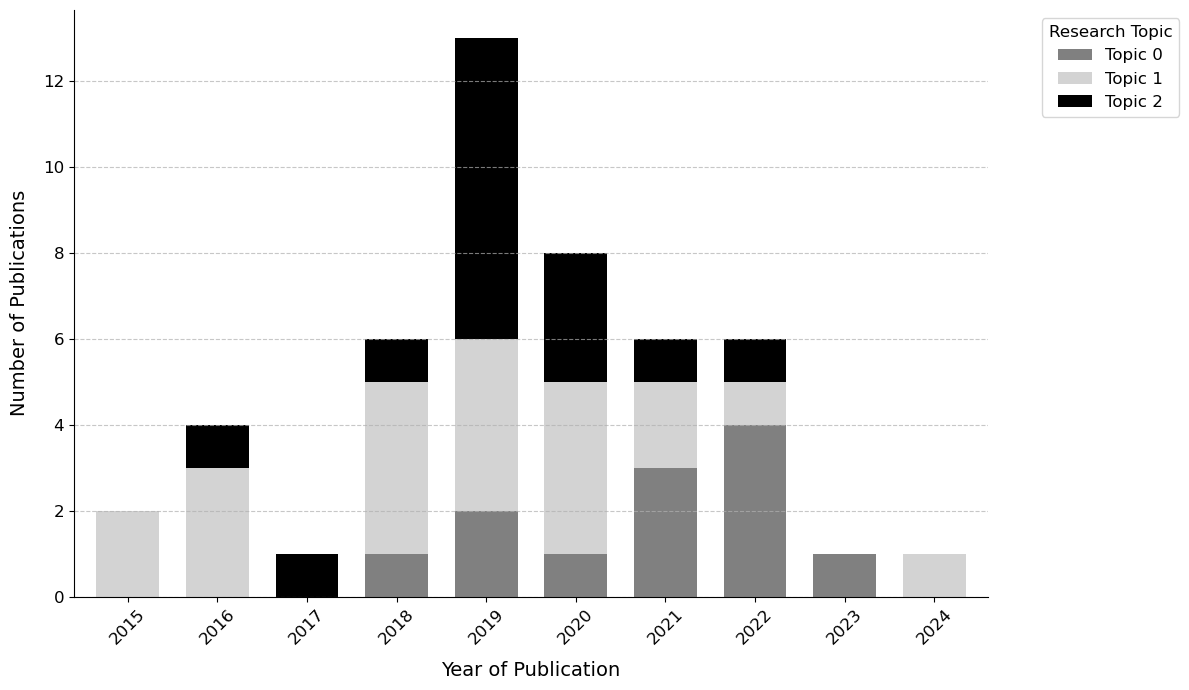

In [5]:
# --- 5. Topic Distribution by Year Plotting ---
# This cell generates the stacked bar chart (Figure 2)
# that visualizes the temporal distribution of the three research topics.
# This plot supports the regression analysis by showing the volume
# and proportion of topics published each year.
# -----------------------------------------------------------------

# 5.1. Define the Data
# This data is derived from Table 2 (Topic assignments) and the
# corrected full reference list (Year assignments).
data = {
    'year': [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024],
    'Topic 0': [0, 0, 0, 1, 2, 1, 3, 4, 1, 0],
    'Topic 1': [2, 3, 0, 4, 4, 4, 2, 1, 0, 1],
    'Topic 2': [0, 1, 1, 1, 7, 3, 1, 1, 0, 0]
}

# Create DataFrame and set 'year' as the index
df2 = pd.DataFrame(data).set_index('year')
# Ensure the column order is Topic 0, 1, 2 for plotting
df2 = df2[['Topic 0', 'Topic 1', 'Topic 2']]

# 5.2. Generate the Stacked Bar Chart
ax = df2.plot(
    kind='bar', 
    stacked=True, 
    figsize=(12, 7),
    color=['gray', 'lightgray', 'black'], 
    width=0.7  # Bar width
)

# 5.3. Set Labels and Titles
# ax.set_title('Distribution of Research Topics by Year', fontsize=14, pad=20)
ax.set_xlabel('Year of Publication', fontsize=14, labelpad=10)
ax.set_ylabel('Number of Publications', fontsize=14, labelpad=10)

# Set the font size for the axis tick labels (the numbers on the axes)
ax.tick_params(axis='both', which='major', labelsize=12)

# Rotate X-axis labels for readability
plt.xticks(rotation=45)

# 5.4. Configure Legend
ax.legend(
    title='Research Topic',
    bbox_to_anchor=(1.05, 1), # Position legend outside the plot
    loc='upper left',
    title_fontsize='12',
    fontsize='12'
)

# 5.5. Clean Up Plot Aesthetics
# Remove the top and right spines for a cleaner look
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
# Add a light grid on the y-axis for readability
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust layout to prevent labels from being cut off
plt.tight_layout()

# 5.6. Save and Show the Plot
plt.savefig('topic_distribution_by_year.png', dpi=300)
plt.show()

Generating word clouds for Figure 3...


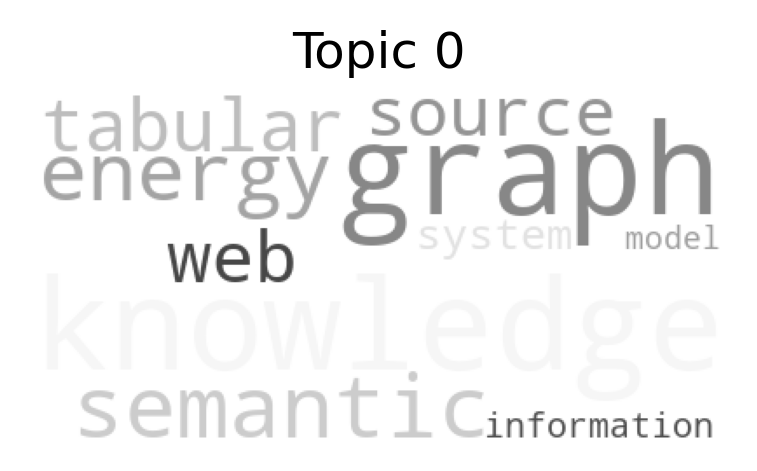

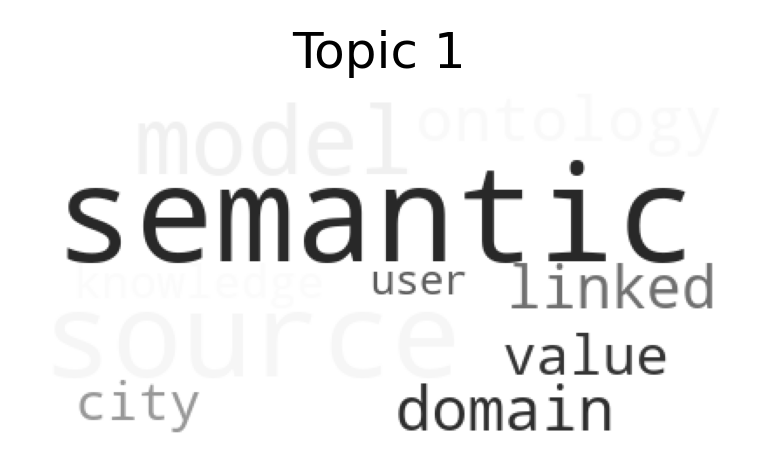

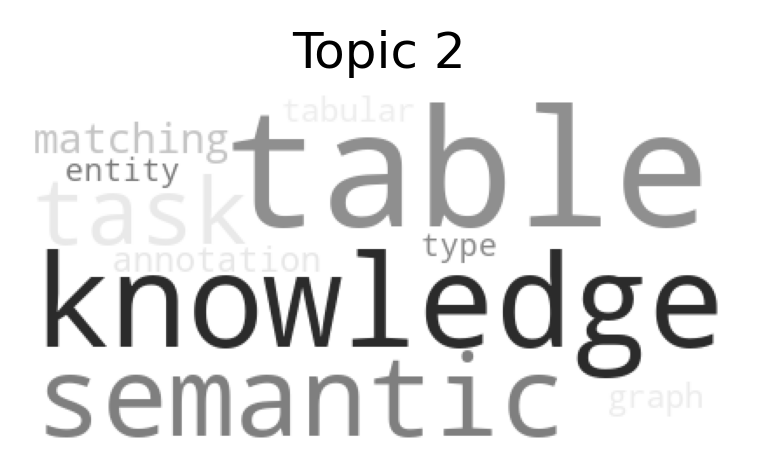

Word cloud generation complete.


In [6]:
# --- 6. Word Cloud Generation (for Figure 3) ---
# This cell uses the 'topic_words_list' and 'topic_word_weights' variables from the
# [cite_start]previous LDA cell (Cell 2) to generate the word clouds for Figure 3[cite: 1083].
# The size of each word is determined by its probability (weight)
# [cite_start]within that topic, as described in the methodology [cite: 1024-1025].
# -----------------------------------------------------------------

# (Optional: For debugging)
# numpy.set_printoptions(threshold=sys.maxsize)

# --- Assumed Variables from LDA Cell 2 ---
# 'topic_words_list': A list of lists, e.g., [['word1', ...], ['wordA', ...]]
# 'topic_word_weights': A list of lists, e.g., [[0.5, ...], [0.8, ...]]
# ----------------------------------------

print("Generating word clouds for Figure 3...")

# Iterate through each topic (0, 1, and 2)
for i in range(0, 3):
    
    topic_frequencies = {}
    
    # Create a frequency dictionary {word: weight} for the current topic
    for word, weight in zip(topic_words_list[i], topic_word_weights[i]):
        topic_frequencies[word] = weight

    # --- Generate the plot ---
    plt.figure(figsize=(3, 3), dpi=300)
    plt.axis("off")
    
    # Generate the word cloud from the calculated frequencies
    plt.imshow(WordCloud(
        background_color="white", 
        colormap="Greys" # Use grayscale to match the paper's style
    ).generate_from_frequencies(topic_frequencies))
    
    plt.title(f"Topic {i}") # English title

    plt.savefig(f'word_cloud_topic_{i}.png', dpi=300)
    plt.show()

print("Word cloud generation complete.")

C:\Users\Colom\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


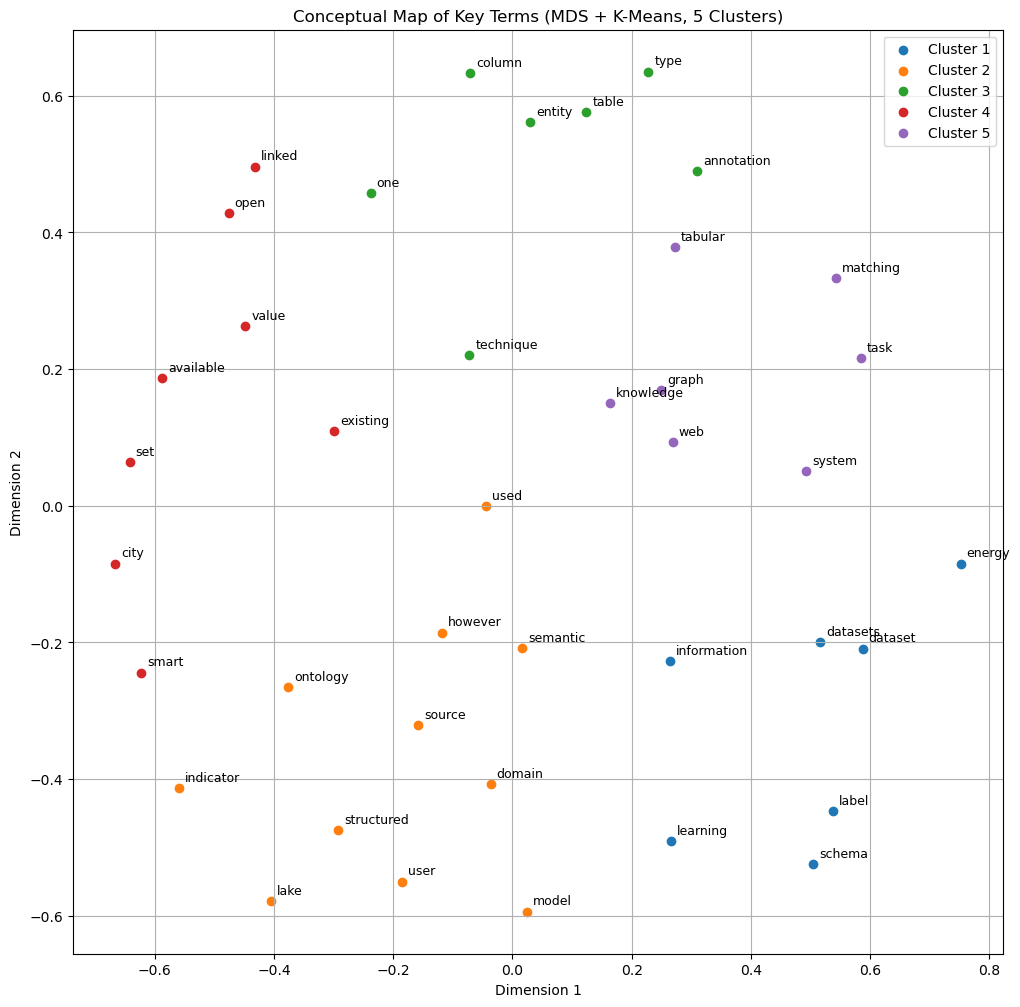

Cluster 1: information, datasets, label, energy, schema, learning, dataset
Cluster 2: semantic, source, model, ontology, domain, lake, however, user, structured, indicator, used
Cluster 3: table, annotation, column, entity, technique, type, one
Cluster 4: linked, value, city, open, existing, smart, available, set
Cluster 5: knowledge, graph, tabular, web, system, task, matching


In [7]:
# 7. Cluster Analysis (Methodology 2.3)
# -----------------------------------------------------------------
# This cell generates the conceptual map (Figure 4) by clustering
# the top keywords based on their co-occurrence patterns.

# 7.1. Get Top-N Most Frequent Keywords
# -----------------------------------------------------------------
# (Assumes 'count_vect' and 'doc_term_matrix' are in memory from the LDA cell)

# Get total count for each word across all documents
sum_words = doc_term_matrix.sum(axis=0) 
# Create a list of (word, frequency) tuples
words_freq = [(word, sum_words[0, idx]) for word, idx in count_vect.vocabulary_.items()]
# Sort by frequency in descending order
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

# [cite_start]Set N for top-N words (as per methodology) [cite: 1162]
num_top_words = 40 
# Get the list of the top N word strings
top_words = [word[0] for word in words_freq[:num_top_words]]

# Get their corresponding indices in the original matrix
top_words_indices = [count_vect.vocabulary_[word] for word in top_words]

# Create a new, sliced document-term matrix [docs, top_words]
top_words_doc_term_matrix = doc_term_matrix[:, top_words_indices]

# 7.2. Compute Term Co-occurrence Similarity
# -----------------------------------------------------------------
# We transpose (.T) the matrix to [top_words, docs] to compute
# the cosine similarity *between words* based on their co-occurrence across documents.
term_similarity_matrix = cosine_similarity(top_words_doc_term_matrix.T)

# 7.3. Dimensionality Reduction (MDS)
# -----------------------------------------------------------------
# Initialize MDS for 2D projection, using a precomputed dissimilarity matrix
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=0, n_init=1)

# Convert similarity matrix to dissimilarity matrix (Distance = 1 - Similarity)
dissimilarity_matrix = 1 - term_similarity_matrix 
# Run MDS to get the 2D coordinates (positions) for each word
pos = mds.fit_transform(dissimilarity_matrix) 

# 7.4. Clustering (K-Means)
# -----------------------------------------------------------------
# [cite_start]Set the number of clusters to 5 (as per methodology) [cite: 1169-1170]
num_clusters = 5 
kmeans = KMeans(n_clusters=num_clusters, random_state=0, n_init=10)
# Run K-Means on the 2D positions to assign each word to a cluster
clusters = kmeans.fit_predict(pos)

# 7.5. Plot Conceptual Map (Generates Figure 4)
# -----------------------------------------------------------------
plt.figure(figsize=(12, 12))
# Plot the points for each cluster with a different color
for i in range(num_clusters):
    cluster_points = pos[clusters == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'Cluster {i+1}')

# Label each point with its corresponding word
for i, word in enumerate(top_words):
    plt.text(pos[i, 0] + 0.01, pos[i, 1] + 0.01, word, fontsize=9)

plt.title(f'Conceptual Map of Key Terms (MDS + K-Means, {num_clusters} Clusters)')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.legend()
plt.grid(True)
plt.savefig('conceptual_map_figure_4.png', dpi=300) # Updated filename
plt.show()

# 7.6. Print Cluster Contents for Interpretation
# -----------------------------------------------------------------
# [cite_start]This provides the raw data for the cluster interpretation in Section 3 [cite: 1158-1202].
for i in range(num_clusters):
    cluster_words_indices = np.where(clusters == i)[0]
    cluster_words = [top_words[idx] for idx in cluster_words_indices]
    print(f"Cluster {i+1}: {', '.join(cluster_words)}")

--- 6.3.a. DIAGNOSIS: Initial (Unadjusted) Model ---
Fitting simple linear model to check assumptions...


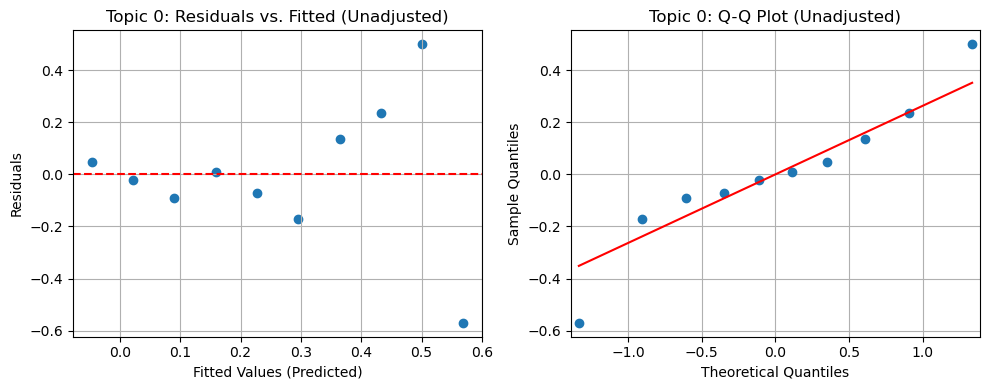

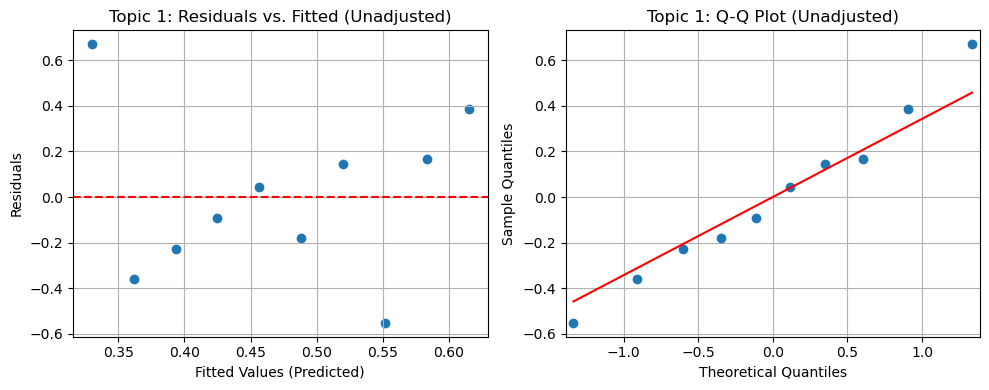

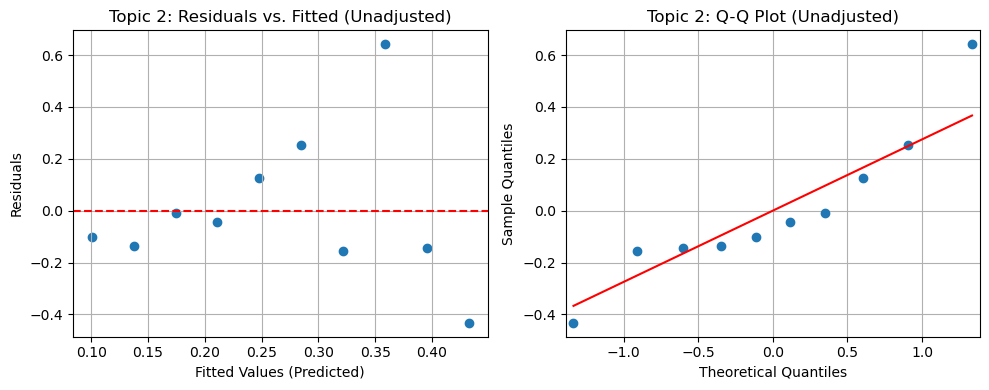


*** DIAGNOSIS COMPLETE: Heteroscedasticity confirmed. ***
Proceeding with log-transformation and full statistical analysis using statsmodels.


--- FINAL MODEL & DIAGNOSTIC: Topic 0 (Log-Transformed) ---
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.362
Model:                            OLS   Adj. R-squared:                  0.282
Method:                 Least Squares   F-statistic:                     4.538
Date:                Sat, 08 Nov 2025   Prob (F-statistic):             0.0658
Time:                        14:44:14   Log-Likelihood:                 2.5224
No. Observations:                  10   AIC:                            -1.045
Df Residuals:                       8   BIC:                           -0.4397
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
     

C:\ProgramData\anaconda3\Lib\site-packages\scipy\stats\_stats_py.py:1736: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


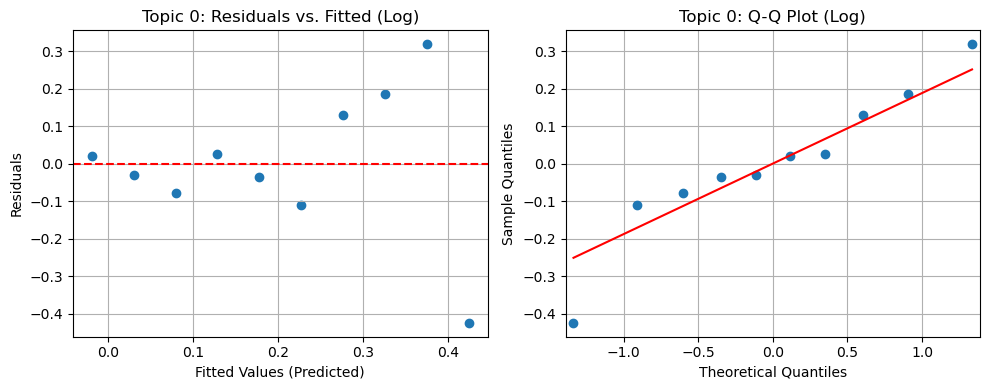


--- FINAL MODEL & DIAGNOSTIC: Topic 1 (Log-Transformed) ---
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                 -0.048
Method:                 Least Squares   F-statistic:                    0.5851
Date:                Sat, 08 Nov 2025   Prob (F-statistic):              0.466
Time:                        14:44:14   Log-Likelihood:                0.21578
No. Observations:                  10   AIC:                             3.568
Df Residuals:                       8   BIC:                             4.174
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------

C:\ProgramData\anaconda3\Lib\site-packages\scipy\stats\_stats_py.py:1736: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


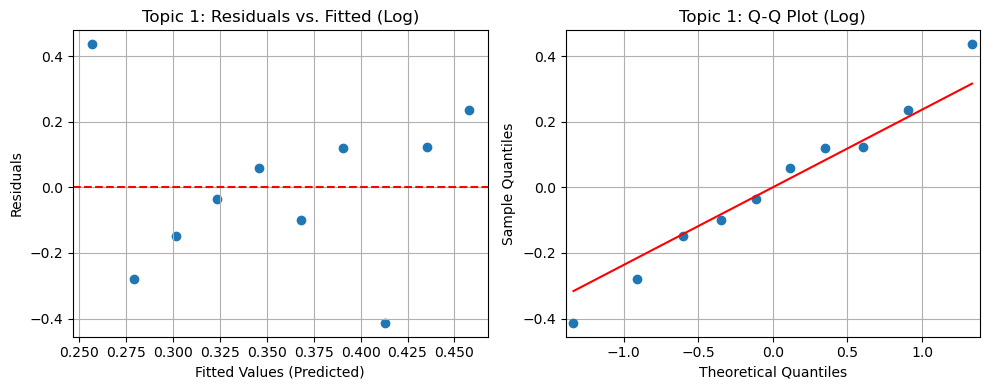


--- FINAL MODEL & DIAGNOSTIC: Topic 2 (Log-Transformed) ---
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.133
Model:                            OLS   Adj. R-squared:                  0.024
Method:                 Least Squares   F-statistic:                     1.225
Date:                Sat, 08 Nov 2025   Prob (F-statistic):              0.301
Time:                        14:44:15   Log-Likelihood:                 2.1900
No. Observations:                  10   AIC:                           -0.3799
Df Residuals:                       8   BIC:                            0.2252
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------

C:\ProgramData\anaconda3\Lib\site-packages\scipy\stats\_stats_py.py:1736: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


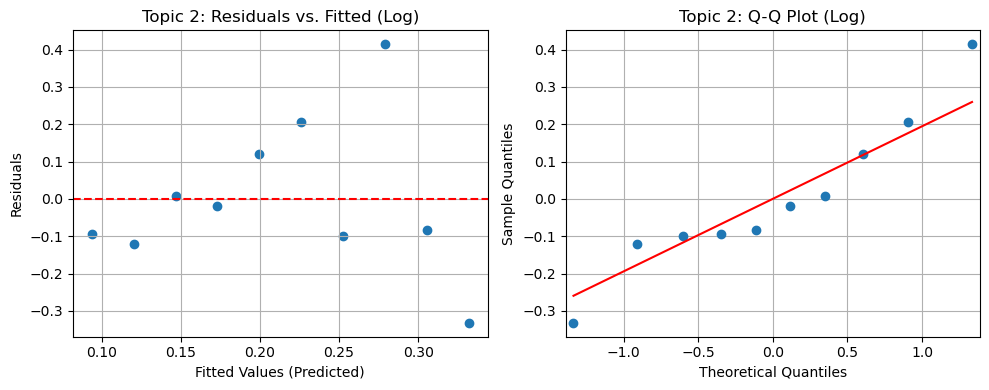


*** FINAL ANALYSIS COMPLETE ***


In [8]:
# -------------------------------------------------------------------------
# 8. Regression Analysis for Temporal Trends
# This cell follows the methodology from Section 2.4.
# Step 1: Fit a simple linear model to diagnose assumptions.
# Step 2: Fit the final, log-transformed OLS model to generate results.
# -------------------------------------------------------------------------

# --- 8.1. Prevalence Computation ---
# (Assuming 'df' is loaded from the LDA step and has columns 'year' and 'Topic')

# Ensure the year column is numeric
df['year'] = pd.to_numeric(df['year'])

# Calculate annual counts per topic
counts = df.groupby(['year', 'Topic']).size().unstack(fill_value=0)
# Calculate total publications per year
total_per_year = counts.sum(axis=1)
# Compute the relative prevalence (percentage) of each topic per year
prevalence_pct = counts.div(total_per_year, axis=0)

# --- 8.2. Prepare Variables for Regression ---
# X variable (independent): The year
# We use the raw array for statsmodels
X_years = np.array(prevalence_pct.index)
# Add a constant (intercept) for statsmodels
X_with_constant = sm.add_constant(X_years)
# scikit-learn requires a 2D matrix
X_years_reshaped = X_years.reshape(-1, 1)

print("--- 8.3.a. DIAGNOSIS: Initial (Unadjusted) Model ---")
print("Fitting simple linear model to check assumptions...")

for topic in prevalence_pct.columns:
    
    # Y variable (dependent): Get the raw prevalence
    y_prevalence = prevalence_pct[topic].values

    # Fit the standard scikit-learn (unadjusted) OLS model
    model_sklearn = LinearRegression()
    model_sklearn.fit(X_years_reshaped, y_prevalence)
    
    # --- Generate Diagnostic Plots (Unadjusted) ---
    
    # 1. Get fitted values and residuals
    fitted_vals = model_sklearn.predict(X_years_reshaped)
    residuals = y_prevalence - fitted_vals

    plt.figure(figsize=(10, 4))

    # Plot 1: Residuals vs. Fitted (Checking for homoscedasticity)
    # This plot reveals heteroscedasticity (a funnel shape),
    # [cite_start]violating OLS assumptions [cite: 981-982].
    plt.subplot(1, 2, 1)
    plt.scatter(fitted_vals, residuals)
    plt.axhline(0, color='red', linestyle='--')
    plt.title(f'Topic {topic}: Residuals vs. Fitted (Unadjusted)')
    plt.xlabel('Fitted Values (Predicted)')
    plt.ylabel('Residuals')
    plt.grid(True)

    # Plot 2: Q-Q Plot (Checking for normality)
    # This plot uses statsmodels.api (sm) for the visualization
    plt.subplot(1, 2, 2)
    sm.qqplot(residuals, line='s', ax=plt.gca())
    plt.title(f'Topic {topic}: Q-Q Plot (Unadjusted)')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

print("\n*** DIAGNOSIS COMPLETE: Heteroscedasticity confirmed. ***")
print("Proceeding with log-transformation and full statistical analysis using statsmodels.\n")

# --- 8.3.b. FINAL MODEL: Log-Transformed OLS (statsmodels) ---
# -----------------------------------------------------------------
# As diagnosed above, we apply a log(y+1) transformation 
# [cite_start]to stabilize the variance and correct for non-normality [cite: 211-213].

for topic in prevalence_pct.columns:
    
    print(f"\n--- FINAL MODEL & DIAGNOSTIC: Topic {topic} (Log-Transformed) ---")
    
    # Apply log(y+1) transformation
    y_prevalence = prevalence_pct[topic].values
    y_transformed = np.log(y_prevalence + 1)

    # Fit the final OLS (Ordinary Least Squares) model using statsmodels
    model_log = sm.OLS(y_transformed, X_with_constant).fit()

    # Print the full statistical summary (for Table 4)
    # [cite_start]This includes R-squared, p-values, and Durbin-Watson [cite: 449, 454-455].
    print(model_log.summary())

    # --- Generate Diagnostic Plots (Log-Transformed) ---
    
    fitted_vals = model_log.fittedvalues
    residuals = model_log.resid

    plt.figure(figsize=(10, 4))

    # Plot 1: Residuals vs. Fitted (Homoscedasticity confirmed)
    # [cite_start]The funnel pattern is gone, indicating stable variance [cite: 986-988].
    plt.subplot(1, 2, 1)
    plt.scatter(fitted_vals, residuals)
    plt.axhline(0, color='red', linestyle='--')
    plt.title(f'Topic {topic}: Residuals vs. Fitted (Log)')
    plt.xlabel('Fitted Values (Predicted)')
    plt.ylabel('Residuals')
    plt.grid(True)

    # Plot 2: Q-Q Plot (Normality confirmed)
    # [cite_start]The points now follow the red line, confirming normality [cite: 216-217, 1001-1002].
    plt.subplot(1, 2, 2)
    sm.qqplot(residuals, line='s', ax=plt.gca())
    plt.title(f'Topic {topic}: Q-Q Plot (Log)')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

print("\n*** FINAL ANALYSIS COMPLETE ***")